<font color='red'>
Note: Show the stats [ref page](https://docs.scipy.org/doc/scipy/reference/stats.html) and scroll to uniform.
</font>

.

<font color='blue'>
You can see in the reference page the long list of distributions that we can use. All of these have very similar usage, since they inherit from a common base class. 
    
Let's go to the [documentation for the "uniform" distribution](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.uniform.html#scipy.stats.uniform)
    
First we import the 'uniform' class:
</font>

In [1]:
from scipy.stats import uniform

<font color='blue'>
Also we will import numpy, as we usually do when working with numbers. For plotting we will use the matplotlib, which is the basic plotting library in python. Later we will start using seaborn, which is more data-science oriented, but overkill for this video. "
</font>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

<font color='red'>
Scroll to Methods
</font>
.

<font color='blue'>
This is the list of methods that you can use for this class. It is pretty similar across all distribution classes, and for our purposes right now the most important are
    
+ rvs: Random variates.
+ pdf: Probability density function.
+ mean: Mean of the distribution.
+ var: Variance of the distribution.
+ std: Standard deviation of the distribution.
    
The first thing to do is to create an instance of the distribution class. We do this by calling the constructor and passing it two parameters "loc" and "scale". These same parameters are used to define many distributions in SciPy, and they can have different meaning in each case. For uniform distributions loc is the mean and scale is half of the width of the distribution. So this line will generate a uniform random variable with values ranging from 10 to 15. 
</font>

\begin{align*}
loc &= a \\
scale &= b-a
\end{align*}



In [47]:
a = 10
b = 3
loc = a
scale = (b-a)

U = uniform(loc, scale)

print(loc, scale)


10 -7


<font color='blue'>
Let's plot this distribution. We can evaluate the pdf with the pdf function that is attached to the object. x here is a numpy array with 100 equally spaced numbers from 5 to 20. The second line evaluates the distribution on all of those 100 values, and stores the result in y. The third line draws the plot. Notice that the height of the distribution is 0.2, which is 1/(b-a) as expected.
</font>

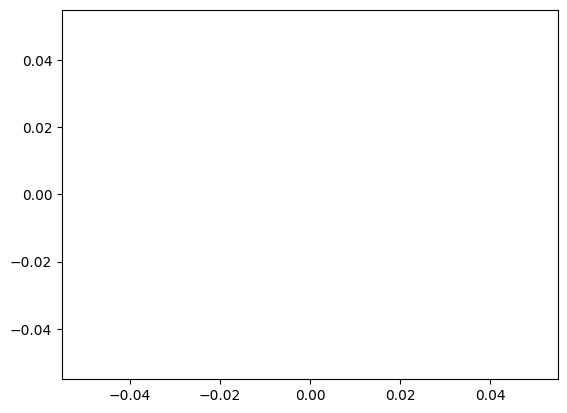

In [48]:
uspace = np.linspace(5, 20, 100)
pU = U.pdf(uspace)
plt.plot(uspace, pU)

<font color='blue'>
The mean, var, and std functions of the distribution object return the mean, variance, and standard deviation of the distribution. We can compare this to the formula we have for these quantities.
</font>

In [49]:
U.mean(), U.var(), U.std()

(np.float64(nan), np.float64(nan), np.float64(nan))

In [50]:
a = 10
b = 3
print('mean = {0}'.format( (a+b)/2 ))
print('var = {0}'.format(  (b-a)**2/12 ))
print('str = {0}'.format(  (b-a)/np.sqrt(12) ))

mean = 6.5
var = 4.083333333333333
str = -2.0207259421636903


# Sampling

<font color='blue'>
Finally, we use the 'random variates' function rvs to sample from a distribution object. we pass in the number of sample size, and this returns a numpy array with the values.
</font>

In [12]:
U.rvs(size=3)

array([11.30081832, 10.09404629, 10.80294406])

<font color='blue'>
We can use rsv to generate, say, 100 samples from U. and then visualize them in a histogram.
</font>

(array([18., 15.,  8., 11., 13., 22., 14., 10., 15., 11.,  9., 22., 14.,
        13., 22., 11., 28., 19., 16.,  9.]),
 array([10.03074111, 10.27867852, 10.52661593, 10.77455334, 11.02249074,
        11.27042815, 11.51836556, 11.76630297, 12.01424037, 12.26217778,
        12.51011519, 12.7580526 , 13.00599   , 13.25392741, 13.50186482,
        13.74980223, 13.99773963, 14.24567704, 14.49361445, 14.74155186,
        14.98948926]),
 <BarContainer object of 20 artists>)

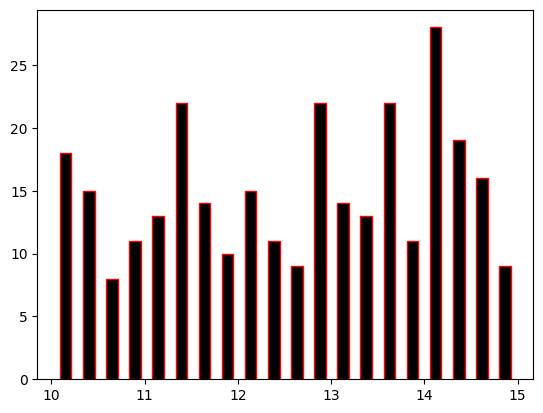

In [43]:
plt.hist( U.rvs(size=300) , bins=20 , rwidth=0.5 , color='black', edgecolor='red')

<font color='blue'>
Let's overlay our histogram with the distribution that generated it. This time when we plot the histogram we will pass the parameter density equals True. This will tell the program to scale the histogram down to the size of a probability density function. 
    
We can increase the number of samples to say 10000, and observe that the histogram looks more and more like the distribution.
</font>

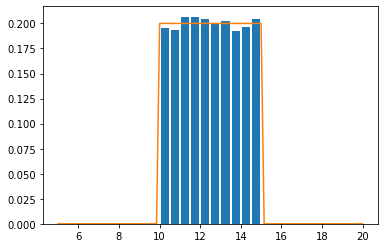

In [ ]:
plt.hist( U.rvs(size=10000), rwidth=0.8, density=True)
plt.plot( uspace, pU)

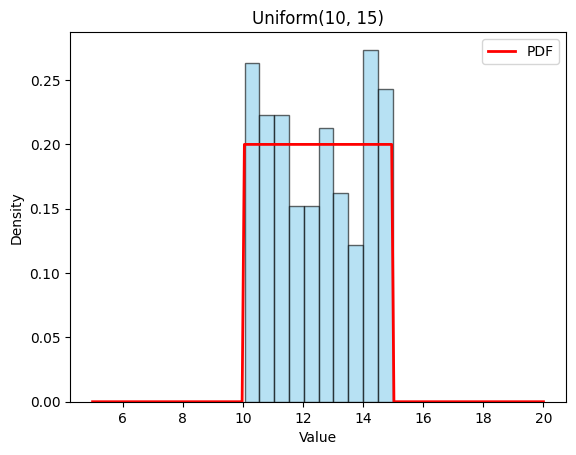

In [45]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import uniform

U = uniform(loc=10, scale=5)

# Sample data
samples = U.rvs(size=200)

# Histogram (empirical)
plt.hist(samples, bins=10, density=True, alpha=0.6, color='skyblue', edgecolor='black')

# Theoretical PDF
uspace = np.linspace(5, 20, 200)
pU = U.pdf(uspace)
plt.plot(uspace, pU, 'r-', lw=2, label="PDF")

plt.title("Uniform(10, 15)")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

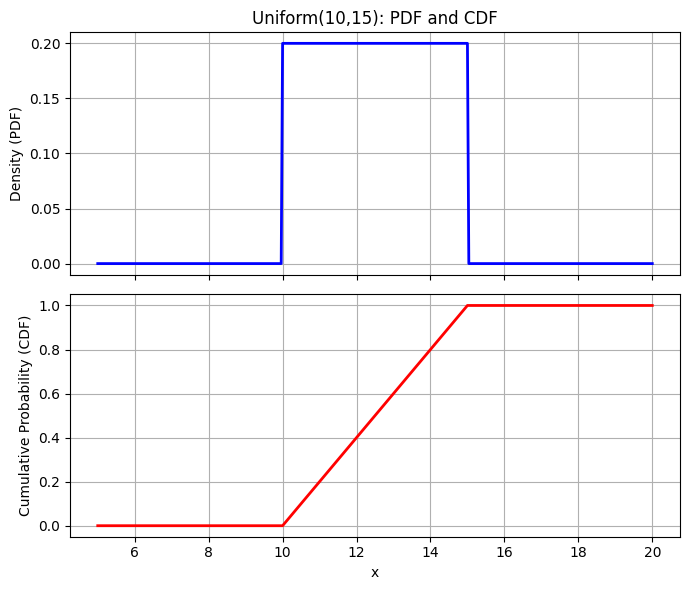

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

# Define distribution: Uniform(10,15)
dist = uniform(loc=10, scale=5)

# X values for plotting
x = np.linspace(5, 20, 400)

# PDF and CDF
pdf_vals = dist.pdf(x)
cdf_vals = dist.cdf(x)

# Create figure with 2 subplots
fig, axs = plt.subplots(2, 1, figsize=(7,6), sharex=True)

# PDF plot
axs[0].plot(x, pdf_vals, 'b-', lw=2)
axs[0].set_title("Uniform(10,15): PDF and CDF")
axs[0].set_ylabel("Density (PDF)")
axs[0].grid(True)

# CDF plot
axs[1].plot(x, cdf_vals, 'r-', lw=2)
axs[1].set_xlabel("x")
axs[1].set_ylabel("Cumulative Probability (CDF)")
axs[1].grid(True)

plt.tight_layout()
plt.show()